# 06B v3 — LungDev Harmony audit, CAGRA graph, and H5AD-safe provenance

This notebook reruns **only notebook 06B** from the completed 06A PCA
checkpoint. Notebook 06A does not need to be repeated.

## What this revision fixes

The previous 06B v2 run completed Harmony, the before/after mixing audit,
CAGRA neighbors, UMAP, and Leiden, but failed when writing the graph H5AD.
The failing field was:

```text
uns["rapids_graph_provenance"]["harmony_subset_neighbor_mixing"]
```

It had been stored as a `list[dict]`, which AnnData/HDF5 attempted to encode as
a variable-length string array.

This version:

1. converts DataFrame summaries to nested dictionaries keyed by row name;
2. recursively sanitizes all `.uns` metadata for H5AD compatibility;
3. converts any remaining `list[dict]` or other structured list to a mapping;
4. converts NumPy/CuPy scalars and arrays safely;
5. performs a tiny metadata-only H5AD serialization preflight;
6. removes incomplete temporary files before retrying;
7. validates the complete graph checkpoint by reading it back;
8. writes to a new `06B_graph_harmony_audit_v3_h5adsafe` directory.

The Harmony-audit and CAGRA logic from v2 is otherwise preserved.


In [1]:
# FIRST CELL — run before any CUDA import
import os

GPU_IDS = os.environ.get(
    "LUNGDEV_RAPIDS_GPU_IDS",
    "0,1,2,3",
)
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS

print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])


CUDA_VISIBLE_DEVICES: 0,1,2,3


In [2]:
# ---------------------------------------------------------------------
# Imports and configuration
# ---------------------------------------------------------------------
from __future__ import annotations

import gc
import hashlib
import importlib.metadata as metadata
import importlib.util
import json
import re
import math
import os
import shutil
import sys
import time
import traceback
import warnings
from pathlib import Path

import anndata as ad
import cupy as cp
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rapids_singlecell as rsc
import scanpy as sc
import scipy.sparse as sp
import zarr

from dask.distributed import Client
from dask_cuda import LocalCUDACluster
from packaging.version import Version
from IPython.display import display

warnings.filterwarnings("ignore")
sc.settings.verbosity = 2
sc.settings.set_figure_params(
    dpi=100,
    frameon=False,
    fontsize=9,
)

PROJECT_ROOT = Path(
    "/host_root/nethome/reny28/Projects/ShortProject/"
    "LungDev_VisiumHD_example"
)
PIPELINE_ROOT = (
    PROJECT_ROOT
    / "tmp"
    / "lungdev_stardist_proseg_resolvi_v1"
)
CORRECTED_ROOT = (
    PIPELINE_ROOT / "05_resolvi_corrected_zarr"
)
RAPIDS_ROOT = PIPELINE_ROOT / "06_rapids_multigpu"
PCA_ROOT = RAPIDS_ROOT / "06A_pca"
GRAPH_ROOT = RAPIDS_ROOT / "06B_graph_harmony_audit_v3_h5adsafe"
FIGURE_ROOT = GRAPH_ROOT / "figures"
TABLE_ROOT = GRAPH_ROOT / "tables"
DASK_LOCAL_DIRECTORY = GRAPH_ROOT / "dask_tmp"

for directory in [
    GRAPH_ROOT,
    FIGURE_ROOT,
    TABLE_ROOT,
    DASK_LOCAL_DIRECTORY,
]:
    directory.mkdir(parents=True, exist_ok=True)

SAMPLE_IDS = [
    "D142_RLL_5B1_8",
    "D430_RLL_7A2_6",
    "D327_RLL_4A2_6",
    "D194_RLL_5A2_6",
]

PCA_CHECKPOINT_H5AD = (
    PCA_ROOT / "LungDev_RAPIDS_PCA80_checkpoint.h5ad"
)
PCA_MANIFEST_JSON = (
    PCA_ROOT / "LungDev_RAPIDS_PCA80_manifest.json"
)
STAGE_X_ZARR = (
    PCA_ROOT / "LungDev_corrected_HVG_raw10k_float32.zarr"
)
STAGE_OBS_PARQUET = (
    PCA_ROOT / "LungDev_corrected_HVG_obs.parquet"
)
STAGE_VAR_PARQUET = (
    PCA_ROOT / "LungDev_corrected_HVG_var.parquet"
)
STAGE_MANIFEST_JSON = (
    PCA_ROOT / "LungDev_corrected_HVG_stage_manifest.json"
)

CORRECTED_LAYER_CANDIDATES = (
    "resolvi_corrected",
    "resolvi_corrected_10k",
)

# Harmony / graph
HARMONY_GPU = 0
HARMONY_FLAVOR_REQUESTED = "harmony1"

# Moderately stronger than the first-pass defaults.
HARMONY_THETA = 4.0
HARMONY_TAU = 0
HARMONY_RIDGE_LAMBDA = 0.5
HARMONY_SIGMA = 0.1
HARMONY_N_CLUSTERS = 100
HARMONY_MAX_ITER = 20
HARMONY_MAX_ITER_CLUSTERING = 200
HARMONY_TOL = 1e-4
HARMONY_TOL_CLUSTERING = 1e-5
HARMONY_BLOCK_PROPORTION = 0.05

# Refuse a no-op adjusted embedding.
HARMONY_MIN_RELATIVE_L2_CHANGE = 1e-5

# Stratified before/after neighborhood audit.
HARMONY_AUDIT_MAX_CELLS = 100_000
HARMONY_AUDIT_NEIGHBORS = 30

N_HARMONY_PCS_FOR_GRAPH = 60
N_NEIGHBORS = 30

# Use one graph algorithm for the audit and production result. The 750k x 60
# embedding is compact enough for one 24-GB GPU.
NEIGHBOR_ALGORITHM = "cagra"

UMAP_MIN_DIST = 0.3
UMAP_INIT_POS = "random"

LEIDEN_RESOLUTIONS = (
    0.3,
    0.5,
    0.8,
    1.0,
    1.5,
)
ANNOTATION_LEIDEN_KEY = "leiden_0p8"
RANDOM_SEED = 17

# Dask cluster
DASK_DEVICE_MEMORY_LIMIT = "18GB"
DASK_RMM_POOL_SIZE = "10GB"
DASK_RMM_MAXIMUM_POOL_SIZE = "18GB"
DASK_HOST_MEMORY_LIMIT_PER_WORKER = "80GB"
DASK_PROTOCOL = "tcp"
DASK_THREADS_PER_WORKER = 1

# Annotation support
RUN_SIGNATURE_SCORING = True
RUN_GPU_CLUSTER_MARKERS = False
MARKER_TOP_N_GENES = 100
MARKER_N_BINS = 500

# Plotting
PLOT_MAX_CELLS = 250_000

# Reuse
OVERWRITE_GRAPH_CHECKPOINT = False
OVERWRITE_MARKERS = False

HARMONY_NPY = (
    GRAPH_ROOT / "LungDev_X_pca_harmony_v3_float32.npy"
)
GRAPH_CHECKPOINT_H5AD = (
    GRAPH_ROOT
    / "LungDev_RAPIDS_Harmony_v3_CAGRA_UMAP_Leiden.h5ad"
)
GRAPH_MANIFEST_JSON = (
    GRAPH_ROOT / "LungDev_RAPIDS_graph_v3_manifest.json"
)
NEIGHBOR_STATUS_JSON = (
    GRAPH_ROOT / "neighbor_search_v2_status.json"
)
MARKER_ERROR_JSON = (
    GRAPH_ROOT / "gpu_marker_ranking_ERROR.json"
)
HARMONY_AUDIT_JSON = (
    GRAPH_ROOT / "Harmony_embedding_audit.json"
)
HARMONY_SUBSET_MIXING_CSV = (
    TABLE_ROOT / "Harmony_subset_neighbor_mixing.csv"
)
INTEGRATION_AUDIT_CSV = (
    TABLE_ROOT / "integration_audit_summary.csv"
)
CLUSTER_SAMPLE_PURITY_CSV = (
    TABLE_ROOT / "leiden_0p8_cluster_sample_purity.csv"
)

print("Python:", sys.executable)
print("Visible GPUs:", cp.cuda.runtime.getDeviceCount())
print("Graph output:", GRAPH_ROOT)


/home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/bin/python
Visible GPUs: 4
Graph output: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06B_graph_harmony_audit_v3_h5adsafe


In [3]:
# ---------------------------------------------------------------------
# Preflight and checkpoint validation
# ---------------------------------------------------------------------
for path in [
    PCA_CHECKPOINT_H5AD,
    PCA_MANIFEST_JSON,
    STAGE_X_ZARR,
    STAGE_OBS_PARQUET,
    STAGE_VAR_PARQUET,
    STAGE_MANIFEST_JSON,
]:
    if not path.exists():
        raise FileNotFoundError(path)

def detect_rapids_singlecell_version():
    """
    Detect the installed rapids-singlecell version across source and
    CUDA-specific wheel distribution names.

    The import package is always ``rapids_singlecell``, but recent prebuilt
    wheels can be distributed as ``rapids-singlecell-cu13`` or
    ``rapids-singlecell-cu12``.
    """
    distribution_candidates = []

    # Ask importlib which installed distribution provides this import package.
    provider_map = metadata.packages_distributions()
    distribution_candidates.extend(
        provider_map.get("rapids_singlecell", [])
    )

    # Explicit fallbacks for current and historical installation names.
    distribution_candidates.extend(
        [
            "rapids-singlecell-cu13",
            "rapids-singlecell-cu12",
            "rapids-singlecell",
            "rapids_singlecell",
        ]
    )

    # Preserve order while removing duplicates.
    distribution_candidates = list(
        dict.fromkeys(distribution_candidates)
    )

    lookup_errors = {}

    for distribution_name in distribution_candidates:
        try:
            version_text = metadata.version(
                distribution_name
            )
            return (
                Version(str(version_text)),
                distribution_name,
            )
        except metadata.PackageNotFoundError as exc:
            lookup_errors[distribution_name] = str(exc)

    # Editable/source installs can expose a module version without normal
    # distribution metadata.
    module_version = getattr(
        rsc,
        "__version__",
        None,
    )

    if module_version not in {None, ""}:
        return (
            Version(str(module_version)),
            "rapids_singlecell.__version__",
        )

    # Last fallback for packages generated with versioneer/hatch-vcs layouts.
    try:
        from rapids_singlecell._version import __version__

        return (
            Version(str(__version__)),
            "rapids_singlecell._version.__version__",
        )
    except Exception:
        pass

    raise RuntimeError(
        "rapids_singlecell imported successfully, but its version could "
        "not be determined from any known distribution or module attribute.\n"
        f"Module file: {getattr(rsc, '__file__', 'unknown')}\n"
        f"Distribution candidates: {distribution_candidates}\n"
        f"Lookup errors: {lookup_errors}"
    )


rsc_version, rsc_distribution_name = (
    detect_rapids_singlecell_version()
)

print(
    "rapids-singlecell:",
    rsc_version,
    f"(detected from {rsc_distribution_name})",
)
print(
    "rapids_singlecell module:",
    getattr(rsc, "__file__", "unknown"),
)

if rsc_version < Version("0.11.0"):
    raise RuntimeError(
        "rapids-singlecell >= 0.11.0 is required."
    )

requested_gpu_count = len(
    [
        value
        for value in GPU_IDS.split(",")
        if value.strip()
    ]
)
if (
    cp.cuda.runtime.getDeviceCount()
    != requested_gpu_count
):
    raise RuntimeError(
        "GPU visibility does not match GPU_IDS. "
        "Restart the kernel and run the first cell first."
    )


def hash_index(values) -> str:
    digest = hashlib.sha256()
    for value in values:
        digest.update(str(value).encode("utf-8"))
        digest.update(b"\n")
    return digest.hexdigest()


pca_manifest = json.loads(
    PCA_MANIFEST_JSON.read_text()
)
stage_manifest = json.loads(
    STAGE_MANIFEST_JSON.read_text()
)

graph = ad.read_h5ad(
    PCA_CHECKPOINT_H5AD
)
graph.obs.index = pd.Index(
    graph.obs.index.astype(str),
    name=None,
)
graph.var.index = pd.Index(
    graph.var.index.astype(str),
    name=None,
)

if (
    hash_index(graph.obs_names)
    != pca_manifest["obs_hash"]
):
    raise ValueError(
        "PCA checkpoint obs order does not match manifest."
    )
if (
    hash_index(graph.var_names)
    != pca_manifest["var_hash"]
):
    raise ValueError(
        "PCA checkpoint var order does not match manifest."
    )

stage_array = zarr.open_array(
    str(STAGE_X_ZARR),
    mode="r",
)
if tuple(stage_array.shape) != graph.shape:
    raise ValueError(
        f"Stage shape {stage_array.shape} does not "
        f"match graph checkpoint {graph.shape}."
    )

print(graph)
print("PCA shape:", graph.obsm["X_pca"].shape)


rapids-singlecell: 0.15.0rc5 (detected from rapids-singlecell-cu13)
rapids_singlecell module: /home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/lib/python3.13/site-packages/rapids_singlecell/__init__.py
AnnData object with n_obs × n_vars = 749761 × 3975
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'cluster', 'volume', 'surface_area', 'scale', 'component', 'cell_area_um2', 'equivalent_2um_bins', 'region', 'prior_qc_keep_bins', 'prior_qc_drop_bins', 'prior_qc_sampled_bins', 'prior_raw_label_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'sample', 'total_counts_deprecated', 'pct_counts_deprecated', 'nodep_total_counts', 'nodep_n_genes_by_counts', 'nodep_total_counts_mt', 'nodep_pct_counts_mt', 'nodep_total_counts_ribo', 'nodep_pct_counts_ribo', 'nodep_total_counts_hb', 'nodep_pct_counts_hb', 'qc_pass', 'q

## 1. Compatibility-safe RAPIDS Harmony with explicit validation

The installed RAPIDS wheel may expose a wrapper that accepts `flavor` but
forwards it to an older compiled/backend function that does not. The helper
below retries only when the exception explicitly names an unsupported keyword.

The notebook records:

- requested and accepted arguments;
- any compatibility removals;
- mean absolute and relative L2 change from PCA;
- sample-centroid dispersion before and after correction;
- per-PC correlations between PCA and Harmony.

Convergence alone is not considered evidence of successful integration.


In [4]:
# ---------------------------------------------------------------------
# Compatibility-safe Harmony and embedding audit
# ---------------------------------------------------------------------
def to_cpu_numpy(value, dtype=None):
    if isinstance(value, cp.ndarray):
        value = cp.asnumpy(value)
    elif hasattr(value, "get"):
        try:
            value = value.get()
        except Exception:
            pass

    value = np.asarray(value)
    if dtype is not None:
        value = value.astype(dtype, copy=False)
    return value


def sample_centroid_dispersion(
    embedding,
    sample_values,
):
    embedding = np.asarray(
        embedding,
        dtype=np.float64,
    )
    sample_values = np.asarray(
        sample_values,
        dtype=str,
    )

    categories = pd.unique(sample_values)
    centroids = np.vstack(
        [
            embedding[
                sample_values == category
            ].mean(axis=0)
            for category in categories
        ]
    )

    pairwise = []
    for left in range(len(categories)):
        for right in range(left + 1, len(categories)):
            pairwise.append(
                float(
                    np.linalg.norm(
                        centroids[left]
                        - centroids[right]
                    )
                )
            )

    return {
        "categories": categories.tolist(),
        "mean_pairwise_centroid_distance": (
            float(np.mean(pairwise))
            if pairwise
            else 0.0
        ),
        "max_pairwise_centroid_distance": (
            float(np.max(pairwise))
            if pairwise
            else 0.0
        ),
    }


def run_harmony_compat(
    adata_obj,
    *,
    basis,
    adjusted_basis,
):
    """
    Run Harmony while removing only explicitly rejected optional keywords.
    """
    requested_kwargs = {
        "key": "sample",
        "basis": basis,
        "adjusted_basis": adjusted_basis,
        "dtype": cp.float64,
        "flavor": HARMONY_FLAVOR_REQUESTED,
        "n_clusters": int(HARMONY_N_CLUSTERS),
        "max_iter_harmony": int(HARMONY_MAX_ITER),
        "max_iter_clustering": int(
            HARMONY_MAX_ITER_CLUSTERING
        ),
        "tol_harmony": float(HARMONY_TOL),
        "tol_clustering": float(
            HARMONY_TOL_CLUSTERING
        ),
        "sigma": float(HARMONY_SIGMA),
        "theta": float(HARMONY_THETA),
        "tau": int(HARMONY_TAU),
        "ridge_lambda": float(
            HARMONY_RIDGE_LAMBDA
        ),
        "block_proportion": float(
            HARMONY_BLOCK_PROPORTION
        ),
        "random_state": int(RANDOM_SEED),
        "verbose": True,
    }

    accepted_kwargs = dict(
        requested_kwargs
    )
    removed = {}

    # Never remove the arguments that define the input/output contract.
    required_arguments = {
        "key",
        "basis",
        "adjusted_basis",
    }

    while True:
        adata_obj.obsm.pop(
            adjusted_basis,
            None,
        )

        try:
            rsc.pp.harmony_integrate(
                adata_obj,
                **accepted_kwargs,
            )
            break

        except Exception as exc:
            message = str(exc)
            match = re.search(
                r"unexpected keyword argument "
                r"['\"]([^'\"]+)['\"]",
                message,
            )

            if match is None:
                raise

            keyword = match.group(1)

            if (
                keyword in required_arguments
                or keyword not in accepted_kwargs
            ):
                raise

            removed[keyword] = {
                "value": str(
                    accepted_kwargs.pop(keyword)
                ),
                "error": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }

            print(
                "Harmony compatibility retry: "
                f"removed unsupported keyword {keyword!r}"
            )

    effective_flavor = (
        accepted_kwargs.get(
            "flavor",
            "legacy_backend_without_flavor_argument",
        )
    )

    serializable_requested = {
        key: (
            str(value)
            if key == "dtype"
            else value
        )
        for key, value in requested_kwargs.items()
    }
    serializable_accepted = {
        key: (
            str(value)
            if key == "dtype"
            else value
        )
        for key, value in accepted_kwargs.items()
    }

    return {
        "requested_kwargs": serializable_requested,
        "accepted_kwargs": serializable_accepted,
        "removed_unsupported_kwargs": removed,
        "effective_flavor": effective_flavor,
    }


pca_cpu = np.asarray(
    graph.obsm["X_pca"],
    dtype=np.float32,
).copy()

if not np.isfinite(pca_cpu).all():
    raise ValueError(
        "X_pca contains NaN or infinity."
    )

sample_values = graph.obs[
    "sample"
].astype(str).to_numpy()

with cp.cuda.Device(HARMONY_GPU):
    graph.obsm["X_pca"] = cp.asarray(
        pca_cpu,
        dtype=cp.float32,
    )

    harmony_compatibility = run_harmony_compat(
        graph,
        basis="X_pca",
        adjusted_basis="X_pca_harmony",
    )

    harmony_cpu = to_cpu_numpy(
        graph.obsm["X_pca_harmony"],
        dtype=np.float32,
    )

graph.obsm["X_pca"] = pca_cpu
graph.obsm["X_pca_harmony"] = (
    harmony_cpu
)
graph.obsm[
    "X_pca_harmony_graph"
] = harmony_cpu[
    :,
    :N_HARMONY_PCS_FOR_GRAPH,
].copy()

if harmony_cpu.shape != pca_cpu.shape:
    raise ValueError(
        f"Harmony shape {harmony_cpu.shape} does not match "
        f"PCA shape {pca_cpu.shape}."
    )

if not np.isfinite(harmony_cpu).all():
    raise ValueError(
        "Harmony output contains NaN or infinity."
    )

difference = (
    harmony_cpu.astype(np.float64)
    - pca_cpu.astype(np.float64)
)

relative_l2_change = float(
    np.linalg.norm(difference)
    / max(
        np.linalg.norm(
            pca_cpu.astype(np.float64)
        ),
        np.finfo(np.float64).eps,
    )
)

per_pc_correlation = []
for component in range(
    pca_cpu.shape[1]
):
    left = pca_cpu[:, component]
    right = harmony_cpu[:, component]

    if (
        np.std(left) == 0
        or np.std(right) == 0
    ):
        per_pc_correlation.append(np.nan)
    else:
        per_pc_correlation.append(
            float(
                np.corrcoef(
                    left,
                    right,
                )[0, 1]
            )
        )

embedding_audit = {
    "shape": list(
        map(int, harmony_cpu.shape)
    ),
    "mean_absolute_change": float(
        np.mean(np.abs(difference))
    ),
    "root_mean_squared_change": float(
        np.sqrt(
            np.mean(
                np.square(difference)
            )
        )
    ),
    "relative_l2_change": relative_l2_change,
    "max_absolute_change": float(
        np.max(np.abs(difference))
    ),
    "median_per_pc_correlation": float(
        np.nanmedian(per_pc_correlation)
    ),
    "minimum_per_pc_correlation": float(
        np.nanmin(per_pc_correlation)
    ),
    "sample_centroids_before": (
        sample_centroid_dispersion(
            pca_cpu[
                :,
                :N_HARMONY_PCS_FOR_GRAPH,
            ],
            sample_values,
        )
    ),
    "sample_centroids_after": (
        sample_centroid_dispersion(
            harmony_cpu[
                :,
                :N_HARMONY_PCS_FOR_GRAPH,
            ],
            sample_values,
        )
    ),
    "compatibility": harmony_compatibility,
}

if (
    relative_l2_change
    < HARMONY_MIN_RELATIVE_L2_CHANGE
):
    raise RuntimeError(
        "Harmony produced a near-no-op embedding: "
        f"relative L2 change={relative_l2_change:.3e}."
    )

graph.uns["harmony_v2_audit"] = (
    embedding_audit
)

HARMONY_AUDIT_JSON.write_text(
    json.dumps(
        embedding_audit,
        indent=2,
        default=str,
    )
)

np.save(
    HARMONY_NPY,
    harmony_cpu,
)

with cp.cuda.Device(HARMONY_GPU):
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

print(
    json.dumps(
        embedding_audit,
        indent=2,
        default=str,
    )
)
print("Wrote:", HARMONY_NPY)


Harmony compatibility retry: removed unsupported keyword 'flavor'
Harmony converged in 10 iterations
{
  "shape": [
    749761,
    80
  ],
  "mean_absolute_change": 2.0858678074101316,
  "root_mean_squared_change": 3.666363981157539,
  "relative_l2_change": 0.5692575985994816,
  "max_absolute_change": 36.73250961303711,
  "median_per_pc_correlation": 0.8677886144696025,
  "minimum_per_pc_correlation": 0.4452725889232937,
  "sample_centroids_before": {
    "categories": [
      "D142_RLL_5B1_8",
      "D430_RLL_7A2_6",
      "D327_RLL_4A2_6",
      "D194_RLL_5A2_6"
    ],
    "mean_pairwise_centroid_distance": 39.289892181981436,
    "max_pairwise_centroid_distance": 52.508096541748145
  },
  "sample_centroids_after": {
    "categories": [
      "D142_RLL_5B1_8",
      "D430_RLL_7A2_6",
      "D327_RLL_4A2_6",
      "D194_RLL_5A2_6"
    ],
    "mean_pairwise_centroid_distance": 4.984622276140379,
    "max_pairwise_centroid_distance": 6.638018673537965
  },
  "compatibility": {
    "req

## 2. Before/after neighborhood-mixing audit on a stratified subset

The same CAGRA algorithm and neighbor count are applied to unintegrated PCA
and Harmony-adjusted PCA on an equally sampled subset of the four donors.

Reported metrics:

```text
cross_sample_edge_fraction
    fraction of directed kNN edges that connect different samples

mean_normalized_sample_lisi
    inverse-Simpson diversity of sample labels in each neighborhood,
    normalized approximately from 0 (one sample) to 1 (all four samples)
```

These metrics quantify mixing but do not determine whether correction is
biologically appropriate. The integrated result should improve them without
collapsing distinct lung lineages.


In [5]:
# ---------------------------------------------------------------------
# Stratified before/after sample-mixing audit
# ---------------------------------------------------------------------
def select_stratified_sample_indices(
    obs,
    *,
    sample_key,
    maximum_cells,
    random_state,
):
    rng = np.random.default_rng(
        random_state
    )
    groups = obs.groupby(
        sample_key,
        observed=True,
    ).indices

    per_group = max(
        1,
        int(maximum_cells // len(groups)),
    )

    selected = []

    for category, indices in groups.items():
        indices = np.asarray(
            indices,
            dtype=np.int64,
        )
        n_select = min(
            per_group,
            len(indices),
        )
        selected.append(
            rng.choice(
                indices,
                size=n_select,
                replace=False,
            )
        )

    return np.sort(
        np.concatenate(selected)
    )


def neighborhood_sample_metrics(
    distances,
    sample_labels,
):
    distances = distances.tocsr()
    sample_codes = pd.Categorical(
        sample_labels
    ).codes
    n_batches = len(
        np.unique(sample_codes)
    )

    cross_edges = 0
    total_edges = 0
    normalized_lisi = np.full(
        distances.shape[0],
        np.nan,
        dtype=np.float64,
    )

    for row in range(
        distances.shape[0]
    ):
        start = distances.indptr[row]
        stop = distances.indptr[row + 1]
        neighbors = distances.indices[
            start:stop
        ]

        # Remove a self-edge if an implementation stores one.
        neighbors = neighbors[
            neighbors != row
        ]

        if len(neighbors) == 0:
            continue

        neighbor_codes = sample_codes[
            neighbors
        ]

        cross_edges += int(
            np.sum(
                neighbor_codes
                != sample_codes[row]
            )
        )
        total_edges += len(neighbors)

        counts = np.bincount(
            neighbor_codes,
            minlength=n_batches,
        ).astype(np.float64)
        proportions = counts / counts.sum()
        inverse_simpson = (
            1.0
            / np.sum(
                np.square(proportions)
            )
        )

        normalized_lisi[row] = (
            (inverse_simpson - 1.0)
            / max(n_batches - 1.0, 1.0)
        )

    return {
        "cross_sample_edge_fraction": float(
            cross_edges
            / max(total_edges, 1)
        ),
        "mean_normalized_sample_lisi": float(
            np.nanmean(normalized_lisi)
        ),
        "median_normalized_sample_lisi": float(
            np.nanmedian(normalized_lisi)
        ),
        "n_cells": int(
            distances.shape[0]
        ),
        "n_directed_edges": int(
            total_edges
        ),
    }


def graph_metrics_for_embedding(
    embedding,
    obs,
    *,
    label,
):
    audit = ad.AnnData(
        X=sp.csr_matrix(
            (len(obs), 1),
            dtype=np.float32,
        ),
        obs=obs.copy(),
    )
    audit.obsm["X_audit"] = cp.asarray(
        embedding,
        dtype=cp.float32,
    )

    with cp.cuda.Device(HARMONY_GPU):
        rsc.pp.neighbors(
            audit,
            n_neighbors=(
                HARMONY_AUDIT_NEIGHBORS
            ),
            use_rep="X_audit",
            algorithm="cagra",
            metric="euclidean",
            random_state=RANDOM_SEED,
        )

    rsc.get.anndata_to_CPU(
        audit,
        convert_all=True,
    )

    metrics = neighborhood_sample_metrics(
        audit.obsp["distances"],
        audit.obs["sample"].astype(str),
    )
    metrics["embedding"] = label

    del audit
    gc.collect()

    with cp.cuda.Device(HARMONY_GPU):
        cp.get_default_memory_pool().free_all_blocks()

    return metrics


audit_indices = select_stratified_sample_indices(
    graph.obs,
    sample_key="sample",
    maximum_cells=HARMONY_AUDIT_MAX_CELLS,
    random_state=RANDOM_SEED,
)

audit_obs = graph.obs.iloc[
    audit_indices
][["sample"]].copy()

audit_rows = []

audit_rows.append(
    graph_metrics_for_embedding(
        pca_cpu[
            audit_indices,
            :N_HARMONY_PCS_FOR_GRAPH,
        ],
        audit_obs,
        label="unintegrated_pca",
    )
)

audit_rows.append(
    graph_metrics_for_embedding(
        harmony_cpu[
            audit_indices,
            :N_HARMONY_PCS_FOR_GRAPH,
        ],
        audit_obs,
        label="harmony",
    )
)

harmony_subset_mixing = pd.DataFrame(
    audit_rows
).set_index("embedding")

harmony_subset_mixing[
    "delta_cross_sample_edge_fraction_vs_pca"
] = (
    harmony_subset_mixing[
        "cross_sample_edge_fraction"
    ]
    - harmony_subset_mixing.loc[
        "unintegrated_pca",
        "cross_sample_edge_fraction",
    ]
)

harmony_subset_mixing[
    "delta_normalized_lisi_vs_pca"
] = (
    harmony_subset_mixing[
        "mean_normalized_sample_lisi"
    ]
    - harmony_subset_mixing.loc[
        "unintegrated_pca",
        "mean_normalized_sample_lisi",
    ]
)

harmony_subset_mixing.to_csv(
    HARMONY_SUBSET_MIXING_CSV
)

display(harmony_subset_mixing)


,cross_sample_edge_fraction,mean_normalized_sample_lisi,median_normalized_sample_lisi,n_cells,n_directed_edges,delta_cross_sample_edge_fraction_vs_pca,delta_normalized_lisi_vs_pca
embedding,,,,,,,
unintegrated_pca,0.001014,0.000019,0.0,100000,2900098,0.00000,0.000000
harmony,0.026605,0.020915,0.0,100000,2900000,0.02559,0.020897


## 3. Production neighbor graph with single-GPU CAGRA

The first-pass graph used multi-GPU IVF-flat. That algorithm completed, but the
sample-separated result did not distinguish insufficient Harmony correction
from an approximate-IVF graph effect.

This revision uses CAGRA for both the audit and the full 750,000-cell graph.
The 60-PC embedding is compact enough to fit comfortably on one 24-GB GPU.


In [6]:
# ---------------------------------------------------------------------
# Dask cluster helper
# ---------------------------------------------------------------------
def start_cuda_cluster():
    base = {
        "CUDA_VISIBLE_DEVICES": GPU_IDS,
        "threads_per_worker": (
            DASK_THREADS_PER_WORKER
        ),
        "protocol": DASK_PROTOCOL,
        "device_memory_limit": (
            DASK_DEVICE_MEMORY_LIMIT
        ),
        "memory_limit": (
            DASK_HOST_MEMORY_LIMIT_PER_WORKER
        ),
        "local_directory": str(
            DASK_LOCAL_DIRECTORY
        ),
    }

    attempts = [
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
            "rmm_maximum_pool_size": (
                DASK_RMM_MAXIMUM_POOL_SIZE
            ),
            "rmm_allocator_external_lib_list": (
                "cupy"
            ),
        },
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
            "rmm_allocator_external_lib_list": (
                "cupy"
            ),
        },
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
        },
        base,
    ]

    failures = []

    for kwargs in attempts:
        try:
            cluster_obj = LocalCUDACluster(
                **kwargs
            )
            client_obj = Client(cluster_obj)
            client_obj.wait_for_workers(
                requested_gpu_count
            )
            return cluster_obj, client_obj, kwargs
        except Exception as exc:
            failures.append(
                {
                    "kwargs": kwargs,
                    "error": (
                        f"{type(exc).__name__}: {exc}"
                    ),
                }
            )
            print(
                "Cluster attempt failed:",
                failures[-1]["error"],
            )

    raise RuntimeError(
        "Unable to start LocalCUDACluster:\n"
        + json.dumps(
            failures,
            indent=2,
            default=str,
        )
    )


In [7]:
# ---------------------------------------------------------------------
# Production CAGRA neighbor graph
# ---------------------------------------------------------------------
neighbor_status = {
    "requested_algorithm": "cagra",
    "algorithm_used": "",
    "fallback_used": False,
    "primary_error": "",
}

with cp.cuda.Device(HARMONY_GPU):
    graph.obsm[
        "X_pca_harmony_graph"
    ] = cp.asarray(
        graph.obsm[
            "X_pca_harmony_graph"
        ],
        dtype=cp.float32,
    )

    rsc.pp.neighbors(
        graph,
        n_neighbors=N_NEIGHBORS,
        use_rep="X_pca_harmony_graph",
        random_state=RANDOM_SEED,
        algorithm="cagra",
        metric="euclidean",
    )

neighbor_status[
    "algorithm_used"
] = "cagra"

NEIGHBOR_STATUS_JSON.write_text(
    json.dumps(
        neighbor_status,
        indent=2,
    )
)

print(json.dumps(neighbor_status, indent=2))


{
  "requested_algorithm": "cagra",
  "algorithm_used": "cagra",
  "fallback_used": false,
  "primary_error": ""
}


## 4. Single-GPU UMAP and Leiden

The distributed workers are closed before this stage. At approximately
750,000 cells, RAPIDS-singlecell recommends single-GPU Leiden rather than the
experimental Dask clustering path.


In [8]:
# ---------------------------------------------------------------------
# UMAP and multi-resolution Leiden on logical GPU 0
# ---------------------------------------------------------------------
with cp.cuda.Device(HARMONY_GPU):
    rsc.tl.umap(
        graph,
        min_dist=UMAP_MIN_DIST,
        init_pos=UMAP_INIT_POS,
        random_state=RANDOM_SEED,
    )

    for resolution in LEIDEN_RESOLUTIONS:
        key = (
            "leiden_"
            + str(resolution).replace(".", "p")
        )

        rsc.tl.leiden(
            graph,
            resolution=float(resolution),
            key_added=key,
            random_state=RANDOM_SEED,
            n_iterations=20,
            use_dask=False,
        )

# Move every supported GPU array/sparse matrix back to CPU.
rsc.get.anndata_to_CPU(
    graph,
    convert_all=True,
)

graph.obs.index = pd.Index(
    graph.obs.index.astype(str),
    name=None,
)
graph.var.index = pd.Index(
    graph.var.index.astype(str),
    name=None,
)

print(
    "Leiden keys:",
    [
        column
        for column in graph.obs
        if column.startswith("leiden_")
    ],
)
print("UMAP shape:", graph.obsm["X_umap"].shape)


Leiden keys: ['leiden_0p3', 'leiden_0p5', 'leiden_0p8', 'leiden_1p0', 'leiden_1p5']
UMAP shape: (749761, 2)


## H5AD-safe checkpointing

The Harmony mixing summary is stored in `.uns` as:

```python
{
    "unintegrated_pca": {...},
    "harmony": {...},
}
```

rather than a list of dictionaries. Before the full graph is written, the
notebook serializes all sanitized metadata into a one-cell test H5AD. A
metadata problem therefore fails quickly without writing a partial 750,000-cell
checkpoint.


In [9]:
# ---------------------------------------------------------------------
# H5AD-safe metadata conversion and graph checkpoint
# ---------------------------------------------------------------------
from collections.abc import Mapping
import copy


def scalar_for_h5ad(value):
    """
    Convert scalar-like metadata to ordinary Python/HDF5-safe values.
    """
    if value is None or value is pd.NA:
        return ""

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(
        value,
        (
            str,
            bytes,
            bool,
            int,
            float,
        ),
    ):
        return value

    # CuPy scalar fallback.
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            pass

    return str(value)


def dataframe_to_h5ad_mapping(
    frame: pd.DataFrame,
):
    """
    Convert a DataFrame to a nested H5AD-safe mapping keyed by row index.

    This intentionally avoids:
        frame.reset_index().to_dict(orient="records")
    because that produces list[dict], which older/current AnnData HDF5
    writers can misinterpret as an object/string array.
    """
    output = {}

    for index, row in frame.iterrows():
        output[str(index)] = {
            str(column): scalar_for_h5ad(value)
            for column, value in row.items()
        }

    return output


def sanitize_for_h5ad(value):
    """
    Recursively convert metadata into structures supported by AnnData/HDF5.

    Key behaviors
    -------------
    - None / pd.NA -> ""
    - Path -> string
    - NumPy/CuPy scalar -> Python scalar
    - pandas DataFrame -> dict[str, dict]
    - pandas Series -> dict
    - list[dict] or nested structured list -> dict indexed by position
    - object-dtype arrays -> recursively sanitized Python structures
    - numeric arrays remain numeric arrays
    """
    if value is None or value is pd.NA:
        return ""

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.DataFrame):
        return dataframe_to_h5ad_mapping(
            value
        )

    if isinstance(value, pd.Series):
        return {
            str(index): sanitize_for_h5ad(item)
            for index, item in value.items()
        }

    if isinstance(value, Mapping):
        return {
            str(key): sanitize_for_h5ad(item)
            for key, item in value.items()
        }

    # CuPy array/scalar fallback without requiring it to remain on GPU.
    if isinstance(value, cp.ndarray):
        value = cp.asnumpy(value)

    if isinstance(value, np.ndarray):
        if value.dtype == object:
            return sanitize_for_h5ad(
                value.tolist()
            )
        return value

    if isinstance(value, (list, tuple)):
        sanitized = [
            sanitize_for_h5ad(item)
            for item in value
        ]

        # Homogeneous scalar lists are supported by AnnData.
        contains_structure = any(
            isinstance(
                item,
                (
                    Mapping,
                    list,
                    tuple,
                ),
            )
            for item in sanitized
        )

        if contains_structure:
            return {
                str(index): item
                for index, item in enumerate(
                    sanitized
                )
            }

        return sanitized

    if isinstance(
        value,
        (
            str,
            bytes,
            bool,
            int,
            float,
        ),
    ):
        return value

    if hasattr(value, "get"):
        try:
            return sanitize_for_h5ad(
                value.get()
            )
        except Exception:
            pass

    if hasattr(value, "item"):
        try:
            return sanitize_for_h5ad(
                value.item()
            )
        except Exception:
            pass

    # Provenance should never prevent saving the biological result.
    return str(value)


def metadata_serialization_preflight(
    uns_mapping,
    *,
    target_path: Path,
) -> None:
    """
    Test only the sanitized .uns metadata in a tiny H5AD before writing
    the 750k-cell graph checkpoint.
    """
    preflight_path = target_path.with_name(
        target_path.stem
        + ".metadata_preflight.h5ad"
    )
    preflight_path.unlink(
        missing_ok=True
    )

    test = ad.AnnData(
        X=sp.csr_matrix(
            (1, 1),
            dtype=np.float32,
        ),
        uns=copy.deepcopy(
            uns_mapping
        ),
    )

    try:
        test.write_h5ad(
            preflight_path,
            compression="lzf",
        )

        check = ad.read_h5ad(
            preflight_path
        )

        if check.shape != (1, 1):
            raise ValueError(
                "Metadata preflight read-back shape mismatch."
            )

    finally:
        preflight_path.unlink(
            missing_ok=True
        )


def atomic_write_h5ad(
    adata_obj: ad.AnnData,
    path: Path,
) -> None:
    """
    Write a graph H5AD atomically after metadata-only serialization testing.
    """
    temp = path.with_name(
        path.stem + ".tmp.h5ad"
    )
    temp.unlink(
        missing_ok=True
    )

    adata_obj.obs.index = pd.Index(
        adata_obj.obs.index.astype(str),
        name=None,
    )
    adata_obj.var.index = pd.Index(
        adata_obj.var.index.astype(str),
        name=None,
    )

    sanitized_uns = sanitize_for_h5ad(
        dict(adata_obj.uns)
    )

    metadata_serialization_preflight(
        sanitized_uns,
        target_path=path,
    )

    # Mutate only after the metadata preflight succeeds.
    adata_obj.uns = sanitized_uns

    try:
        adata_obj.write_h5ad(
            temp,
            compression="lzf",
        )

        check = ad.read_h5ad(
            temp,
            backed="r",
        )

        try:
            if check.shape != adata_obj.shape:
                raise ValueError(
                    "Graph H5AD read-back shape mismatch."
                )

            required_obsm = {
                "X_pca",
                "X_pca_harmony",
                "X_umap",
            }
            missing_obsm = required_obsm.difference(
                set(check.obsm.keys())
            )
            if missing_obsm:
                raise KeyError(
                    "Graph H5AD read-back is missing obsm keys: "
                    f"{sorted(missing_obsm)}"
                )

            required_obsp = {
                "distances",
                "connectivities",
            }
            missing_obsp = required_obsp.difference(
                set(check.obsp.keys())
            )
            if missing_obsp:
                raise KeyError(
                    "Graph H5AD read-back is missing obsp keys: "
                    f"{sorted(missing_obsp)}"
                )

        finally:
            try:
                check.file.close()
            except Exception:
                pass

        temp.replace(path)

    except Exception:
        temp.unlink(
            missing_ok=True
        )
        raise


safe_harmony_subset_mixing = (
    dataframe_to_h5ad_mapping(
        harmony_subset_mixing
    )
)

graph.uns["rapids_graph_provenance"] = {
    "rapids_singlecell_version": str(
        rsc_version
    ),
    "harmony_batch_key": "sample",
    "harmony_audit": embedding_audit,
    "harmony_subset_neighbor_mixing": (
        safe_harmony_subset_mixing
    ),
    "harmony_pcs_for_graph": int(
        N_HARMONY_PCS_FOR_GRAPH
    ),
    "neighbor_status": neighbor_status,
    "production_neighbor_algorithm": "cagra",
    "n_neighbors": int(N_NEIGHBORS),
    "umap_min_dist": float(
        UMAP_MIN_DIST
    ),
    "leiden_resolutions": [
        float(value)
        for value in LEIDEN_RESOLUTIONS
    ],
    "source_pca_checkpoint": str(
        PCA_CHECKPOINT_H5AD
    ),
    "source_corrected_stage": str(
        STAGE_X_ZARR
    ),
}

atomic_write_h5ad(
    graph,
    GRAPH_CHECKPOINT_H5AD,
)

print(
    "Wrote H5AD-safe graph checkpoint:",
    GRAPH_CHECKPOINT_H5AD,
)


Wrote H5AD-safe graph checkpoint: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06B_graph_harmony_audit_v3_h5adsafe/LungDev_RAPIDS_Harmony_v3_CAGRA_UMAP_Leiden.h5ad


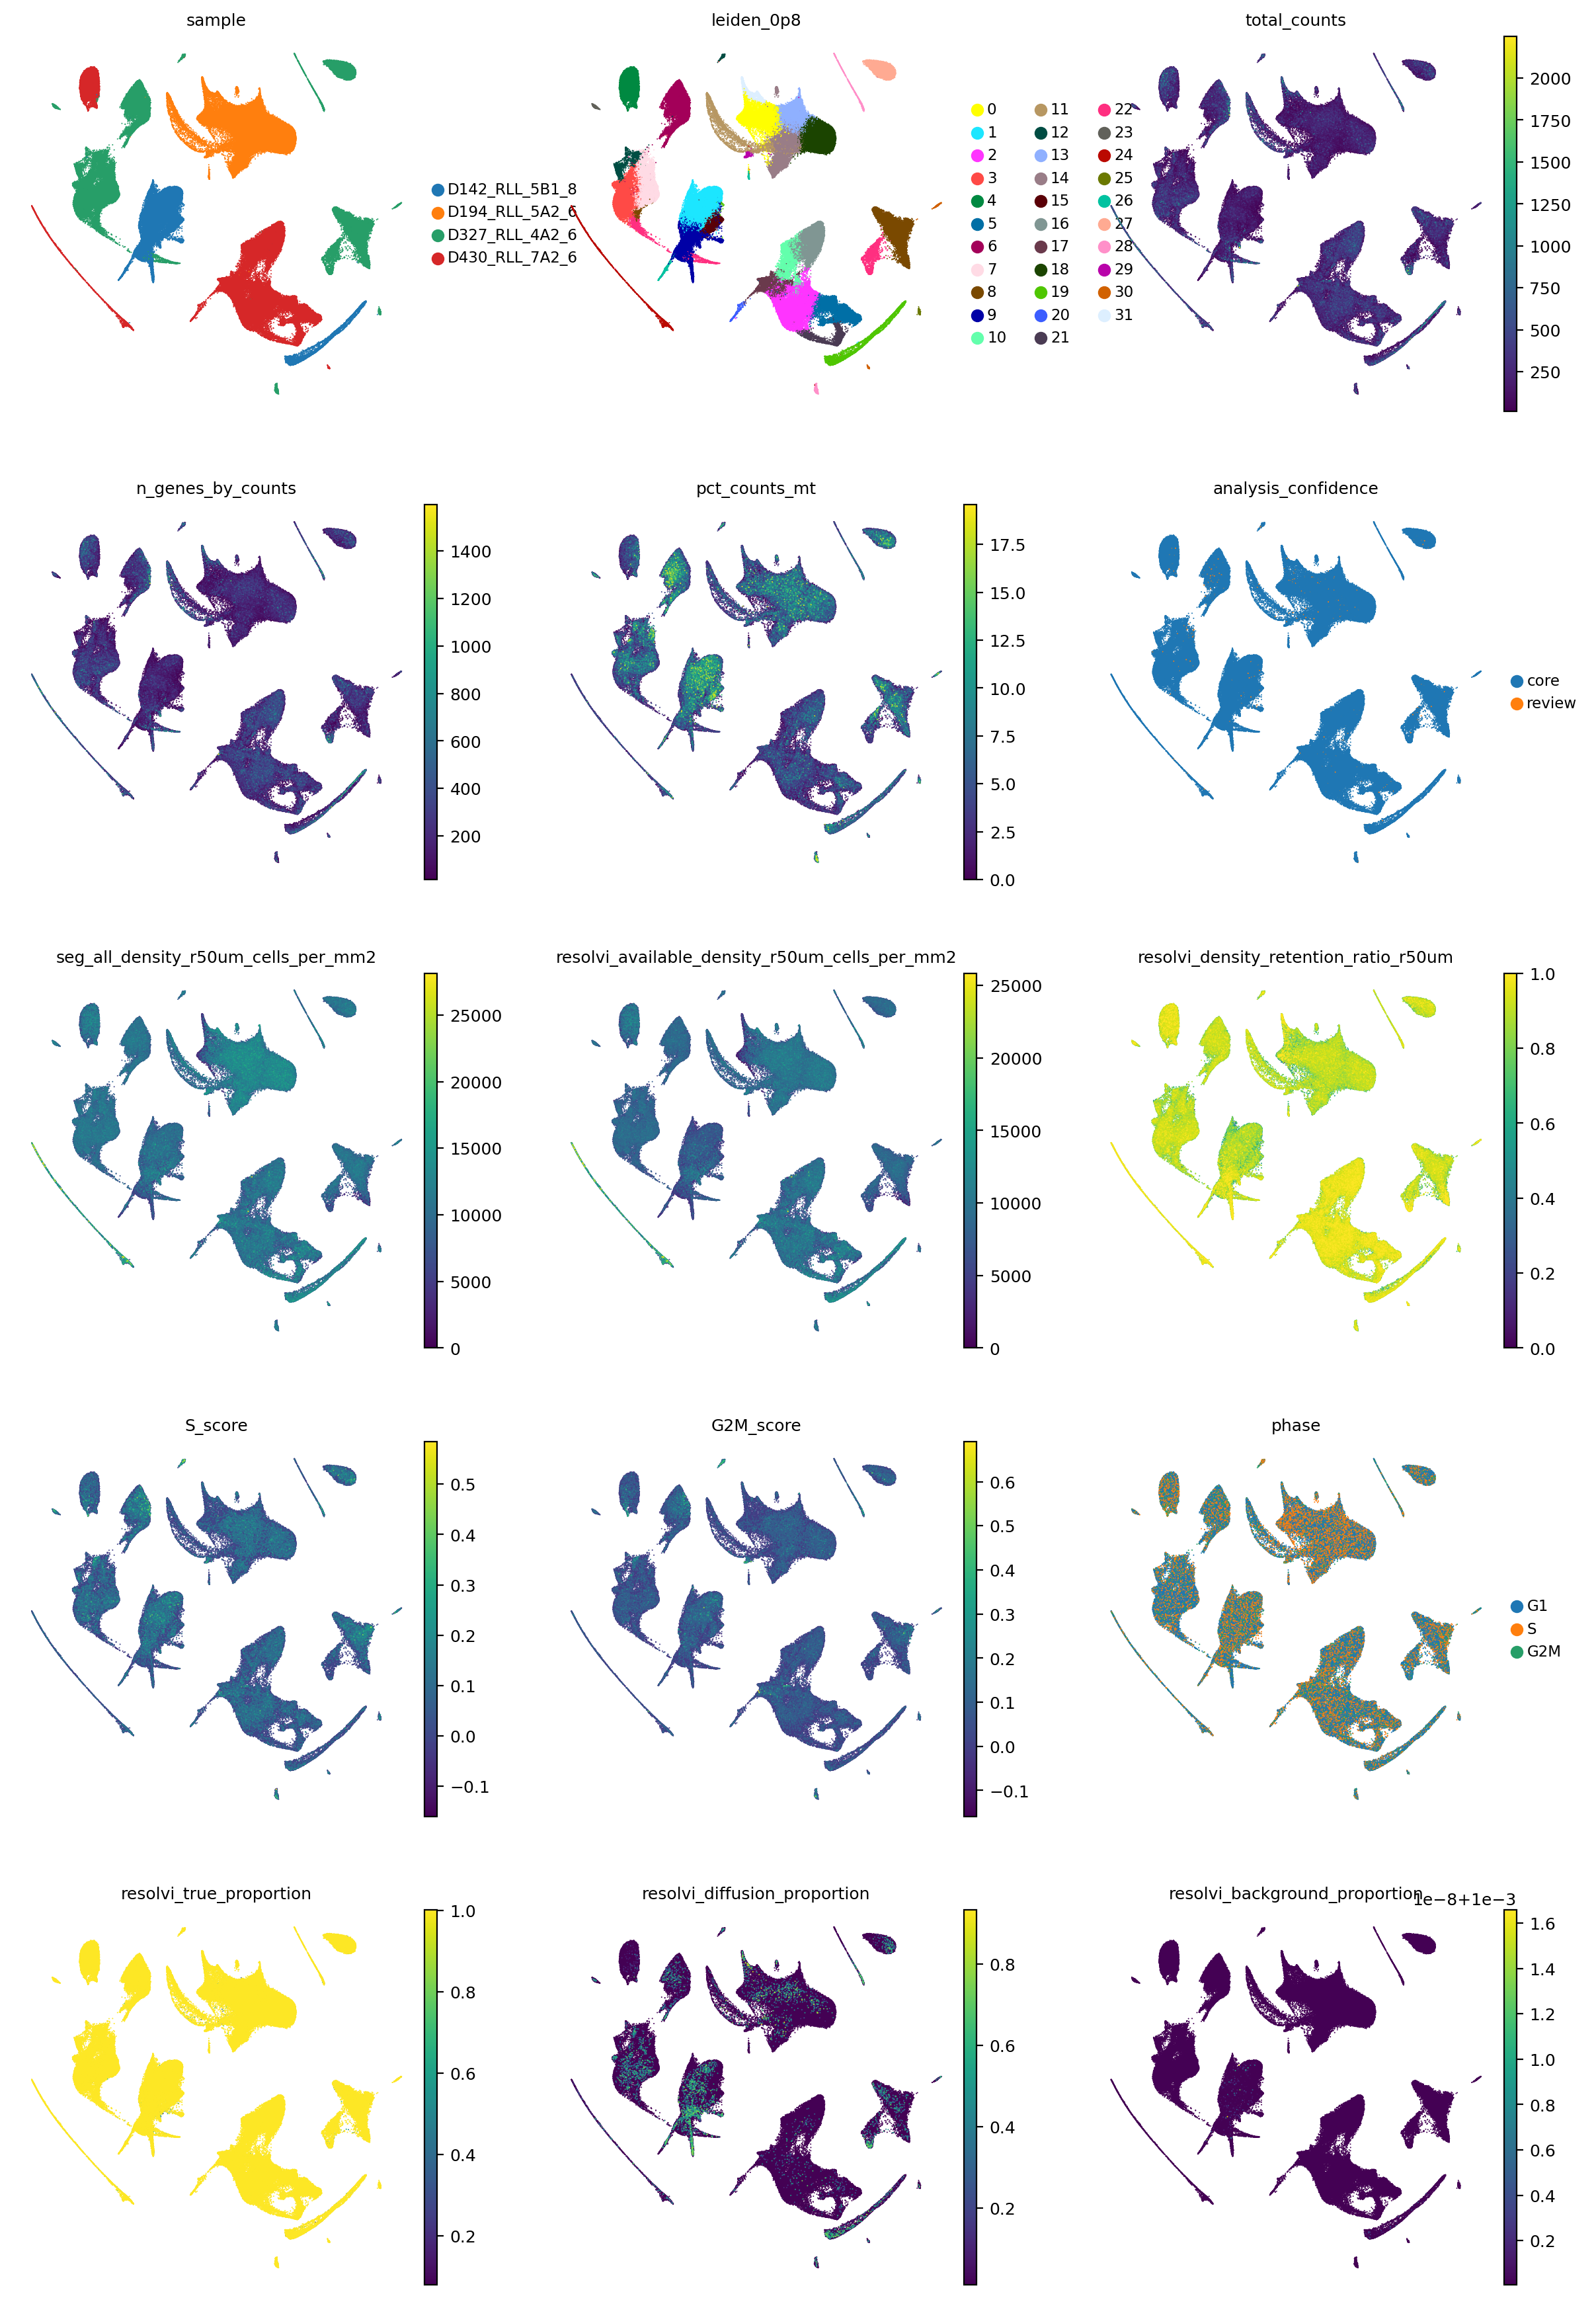

sample,D142_RLL_5B1_8,D194_RLL_5A2_6,D327_RLL_4A2_6,D430_RLL_7A2_6
leiden_0p8,,,,
0,0,41530,0,0
1,68731,0,0,0
2,2,2,2,65434
3,4,1,38167,0
4,12,4,102,21983
5,1,0,0,26943
6,2,4,38883,0
7,1,3,35835,0
8,7,1,42004,0


sample,D142_RLL_5B1_8,D194_RLL_5A2_6,D327_RLL_4A2_6,D430_RLL_7A2_6
leiden_0p8,,,,
0,0.000,1.000,0.000,0.000
1,1.000,0.000,0.000,0.000
2,0.000,0.000,0.000,1.000
3,0.000,0.000,1.000,0.000
4,0.001,0.000,0.005,0.995
5,0.000,0.000,0.000,1.000
6,0.000,0.000,1.000,0.000
7,0.000,0.000,1.000,0.000
8,0.000,0.000,1.000,0.000


,n_cells,dominant_sample,dominant_sample_fraction,normalized_sample_entropy
leiden_0p8,,,,
0,41530,D194_RLL_5A2_6,1.000000,0.000000
1,68731,D142_RLL_5B1_8,1.000000,0.000000
2,65440,D430_RLL_7A2_6,0.999908,0.000754
3,38172,D327_RLL_4A2_6,0.999869,0.000987
4,22101,D430_RLL_7A2_6,0.994661,0.025816
5,26944,D430_RLL_7A2_6,0.999963,0.000300
6,38889,D327_RLL_4A2_6,0.999846,0.001159
7,35839,D327_RLL_4A2_6,0.999888,0.000858
8,42012,D327_RLL_4A2_6,0.999810,0.001366


,full_graph_cross_sample_edge_fraction,full_graph_mean_normalized_sample_lisi,weighted_leiden_0p8_sample_purity,weighted_leiden_0p8_normalized_sample_entropy,n_clusters,n_clusters_at_least_99pct_one_sample,harmony_relative_l2_change
0,0.00233,0.001543,0.99733,0.00549,32,30,0.569258


In [10]:
# ---------------------------------------------------------------------
# QC, batch, density, and cluster diagnostics
# ---------------------------------------------------------------------
rng = np.random.default_rng(
    RANDOM_SEED
)

if graph.n_obs > PLOT_MAX_CELLS:
    # Preserve all samples and the annotation-resolution clusters.
    sampled_indices = []

    grouping = graph.obs[
        ["sample", ANNOTATION_LEIDEN_KEY]
    ].astype(str)

    for _, group_index in grouping.groupby(
        ["sample", ANNOTATION_LEIDEN_KEY]
    ).groups.items():
        group_index = np.asarray(
            [
                graph.obs_names.get_loc(value)
                for value in group_index
            ],
            dtype=np.int64,
        )
        target = max(
            50,
            round(
                PLOT_MAX_CELLS
                * len(group_index)
                / graph.n_obs
            ),
        )
        target = min(
            target,
            len(group_index),
        )
        sampled_indices.extend(
            rng.choice(
                group_index,
                size=target,
                replace=False,
            ).tolist()
        )

    sampled_indices = np.unique(
        sampled_indices
    )
    if len(sampled_indices) > PLOT_MAX_CELLS:
        sampled_indices = rng.choice(
            sampled_indices,
            size=PLOT_MAX_CELLS,
            replace=False,
        )

    plot_data = graph[
        sampled_indices
    ].copy()
else:
    plot_data = graph

plot_columns = [
    "sample",
    ANNOTATION_LEIDEN_KEY,
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "analysis_confidence",
    "seg_all_density_r50um_cells_per_mm2",
    "resolvi_available_density_r50um_cells_per_mm2",
    "resolvi_density_retention_ratio_r50um",
]

for optional in [
    "S_score",
    "G2M_score",
    "phase",
    "resolvi_true_proportion",
    "resolvi_diffusion_proportion",
    "resolvi_background_proportion",
]:
    if optional in plot_data.obs:
        plot_columns.append(optional)

sc.pl.umap(
    plot_data,
    color=plot_columns,
    ncols=3,
    size=2,
    show=False,
)
plt.savefig(
    FIGURE_ROOT
    / "UMAP_QC_batch_density_cellcycle.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

cluster_sample_counts = pd.crosstab(
    graph.obs[ANNOTATION_LEIDEN_KEY],
    graph.obs["sample"],
)
cluster_sample_fractions = (
    cluster_sample_counts.div(
        cluster_sample_counts.sum(axis=1),
        axis=0,
    )
)

cluster_sample_counts.to_csv(
    TABLE_ROOT
    / f"{ANNOTATION_LEIDEN_KEY}_sample_counts.csv"
)
cluster_sample_fractions.to_csv(
    TABLE_ROOT
    / f"{ANNOTATION_LEIDEN_KEY}_sample_fractions.csv"
)

display(cluster_sample_counts)
display(cluster_sample_fractions.round(3))


# ------------------------------------------------------------------
# Quantitative integration audit on the production graph
# ------------------------------------------------------------------
full_neighbor_metrics = neighborhood_sample_metrics(
    graph.obsp["distances"],
    graph.obs["sample"].astype(str),
)

cluster_sample_purity = pd.DataFrame(
    {
        "n_cells": (
            cluster_sample_counts.sum(axis=1)
        ),
        "dominant_sample": (
            cluster_sample_counts.idxmax(axis=1)
        ),
        "dominant_sample_fraction": (
            cluster_sample_counts.max(axis=1)
            / cluster_sample_counts.sum(axis=1)
        ),
    }
)

fraction_matrix = cluster_sample_counts.div(
    cluster_sample_counts.sum(axis=1),
    axis=0,
)

with np.errstate(
    divide="ignore",
    invalid="ignore",
):
    entropy_terms = (
        -fraction_matrix
        * np.log(
            fraction_matrix.replace(0, np.nan)
        )
    )

cluster_sample_purity[
    "normalized_sample_entropy"
] = (
    entropy_terms.sum(axis=1)
    / np.log(
        cluster_sample_counts.shape[1]
    )
)

weighted_cluster_purity = float(
    (
        cluster_sample_purity[
            "dominant_sample_fraction"
        ]
        * cluster_sample_purity[
            "n_cells"
        ]
    ).sum()
    / cluster_sample_purity[
        "n_cells"
    ].sum()
)

weighted_cluster_entropy = float(
    (
        cluster_sample_purity[
            "normalized_sample_entropy"
        ]
        * cluster_sample_purity[
            "n_cells"
        ]
    ).sum()
    / cluster_sample_purity[
        "n_cells"
    ].sum()
)

integration_audit = {
    "full_graph_cross_sample_edge_fraction": (
        full_neighbor_metrics[
            "cross_sample_edge_fraction"
        ]
    ),
    "full_graph_mean_normalized_sample_lisi": (
        full_neighbor_metrics[
            "mean_normalized_sample_lisi"
        ]
    ),
    "weighted_leiden_0p8_sample_purity": (
        weighted_cluster_purity
    ),
    "weighted_leiden_0p8_normalized_sample_entropy": (
        weighted_cluster_entropy
    ),
    "n_clusters": int(
        len(cluster_sample_purity)
    ),
    "n_clusters_at_least_99pct_one_sample": int(
        (
            cluster_sample_purity[
                "dominant_sample_fraction"
            ]
            >= 0.99
        ).sum()
    ),
    "harmony_relative_l2_change": (
        embedding_audit[
            "relative_l2_change"
        ]
    ),
}

cluster_sample_purity.to_csv(
    CLUSTER_SAMPLE_PURITY_CSV
)

pd.DataFrame(
    [integration_audit]
).to_csv(
    INTEGRATION_AUDIT_CSV,
    index=False,
)

graph.uns[
    "integration_audit_v2"
] = integration_audit

display(cluster_sample_purity)
display(
    pd.DataFrame(
        [integration_audit]
    )
)


## 5. Corrected-expression lung marker programs

Only the targeted marker panel is materialized from the complete per-sample
ResolVI-corrected Zarrs. This keeps annotation support independent of whether a
marker gene was selected as an HVG.


In [11]:
# ---------------------------------------------------------------------
# Marker programs and corrected-expression helpers
# ---------------------------------------------------------------------
MARKER_PROGRAMS = {
    "immune": [
        "PTPRC", "LST1", "TYROBP", "FCER1G", "LAPTM5",
    ],
    "epithelial": [
        "EPCAM", "KRT8", "KRT18", "KRT19", "MUC1",
    ],
    "endothelial": [
        "PECAM1", "VWF", "CLDN5", "RAMP2", "KDR",
    ],
    "mesenchymal": [
        "DCN", "LUM", "COL1A1", "COL1A2", "COL3A1",
    ],
    "pericyte_smooth_muscle": [
        "RGS5", "CSPG4", "MCAM", "ACTA2", "TAGLN", "MYH11",
    ],
    "alveolar_type_1": [
        "AGER", "CAV1", "CAV2", "PDPN", "HOPX",
    ],
    "alveolar_type_2": [
        "SFTPA1", "SFTPA2", "SFTPB", "SFTPC", "ABCA3", "NAPSA",
    ],
    "ciliated": [
        "FOXJ1", "PIFO", "TPPP3", "CAPS", "CCDC153",
    ],
    "club_secretory": [
        "SCGB1A1", "SCGB3A1", "KRT19", "CYP2F1",
    ],
    "basal": [
        "KRT5", "KRT14", "KRT17", "TP63", "KRT15",
    ],
    "lymphatic_endothelial": [
        "PROX1", "LYVE1", "PDPN", "CCL21", "FLT4",
    ],
    "fibroblast": [
        "COL1A1", "COL1A2", "COL3A1", "DCN", "LUM", "COL6A1",
    ],
    "macrophage": [
        "LST1", "C1QA", "C1QB", "C1QC", "APOE",
    ],
    "t_cell": [
        "CD3D", "CD3E", "TRBC1", "TRBC2", "LCK",
    ],
    "b_cell": [
        "CD79A", "MS4A1", "CD37", "CD74", "HLA-DRA",
    ],
    "nk_cell": [
        "NKG7", "GNLY", "KLRD1", "PRF1", "GZMB",
    ],
    "neutrophil": [
        "FCGR3B", "CSF3R", "S100A8", "S100A9", "CXCR2",
    ],
}

BROAD_PROGRAMS = [
    "immune",
    "epithelial",
    "endothelial",
    "mesenchymal",
    "pericyte_smooth_muscle",
]


def corrected_path(sample: str) -> Path:
    return (
        CORRECTED_ROOT
        / sample
        / f"{sample}_resolvi_allcells.zarr"
    )


def read_corrected_lazy(path: Path):
    try:
        return ad.experimental.read_lazy(
            str(path),
            load_annotation_index=True,
        )
    except TypeError:
        try:
            group = zarr.open_group(
                str(path),
                mode="r",
            )
            return ad.experimental.read_lazy(
                group,
                load_annotation_index=True,
            )
        except TypeError:
            return ad.experimental.read_lazy(
                str(path)
            )


def resolve_corrected_layer(adata_like) -> str:
    present = [
        candidate
        for candidate in CORRECTED_LAYER_CANDIDATES
        if candidate in adata_like.layers
    ]
    if not present:
        raise KeyError(
            "No supported ResolVI corrected layer found. "
            f"Available: {list(adata_like.layers.keys())}"
        )
    return present[0]


def materialize_array(value):
    if hasattr(value, "compute"):
        value = value.compute()
    if hasattr(value, "to_memory"):
        value = value.to_memory()
    if sp.issparse(value):
        value = value.toarray()
    return np.asarray(value)


,sig_immune,sig_epithelial,sig_endothelial,sig_mesenchymal,sig_pericyte_smooth_muscle,sig_alveolar_type_1,sig_alveolar_type_2,sig_ciliated,sig_club_secretory,sig_basal,sig_lymphatic_endothelial,sig_fibroblast,sig_macrophage,sig_t_cell,sig_b_cell,sig_nk_cell,sig_neutrophil,broad_label_suggested,broad_score_margin
leiden_0p8,,,,,,,,,,,,,,,,,,,
0,-0.496155,-0.742801,-0.016196,0.915023,0.495898,-0.347037,-0.685647,0.046905,-0.061184,-0.005900,0.007499,0.942312,-0.547505,-0.178083,-0.351919,-0.304968,-0.640962,mesenchymal,0.419126
1,-0.124753,0.014213,0.227587,-0.054881,0.401517,0.139389,0.565013,-0.174181,-0.014058,-0.152566,0.057517,-0.076432,-0.082150,0.353281,-0.039491,0.229641,0.005547,pericyte_smooth_muscle,0.173929
2,0.012681,-0.249404,0.704045,0.004919,-0.293921,0.338180,0.467309,-0.129126,-0.270859,-0.226930,0.149431,0.043669,0.015329,0.374521,0.452671,0.352196,0.277212,endothelial,0.691364
3,-0.120098,-0.122777,0.998415,0.190214,0.833033,-0.010076,-0.747512,-0.359919,-0.208663,-0.228917,0.243602,0.144696,-0.059112,-0.377105,-0.443755,-0.120821,0.062882,endothelial,0.165382
4,3.198524,-0.897060,-1.085320,-1.884317,-1.204693,-1.317076,-0.307824,-0.337635,-0.398750,-0.282134,-0.865783,-1.893403,3.218153,-0.398837,1.317978,-0.415186,0.842564,immune,4.095584
5,0.043127,-0.555242,-0.217750,0.788084,0.176929,-0.161257,0.135131,-0.108638,-0.288815,-0.244120,0.350800,0.851064,0.273559,-0.081591,0.274170,-0.213820,-0.204617,mesenchymal,0.611155
6,-0.188254,2.103640,-0.508737,-0.354860,-0.233231,0.565366,0.375241,-0.324164,0.407238,0.024272,-0.271795,-0.473637,-0.214352,-0.378704,-0.477580,-0.301735,-0.003566,epithelial,2.291893
7,0.119283,-0.391695,-0.286539,0.840837,0.275960,-0.182454,-0.768265,-0.417345,-0.286798,-0.226121,0.023455,0.788610,0.248939,-0.310660,-0.395608,-0.177930,0.208543,mesenchymal,0.564878
8,-0.167616,-0.583630,-0.680834,1.260224,0.334053,-0.276222,-0.994779,-0.450871,-0.349803,-0.239588,0.213208,1.223709,0.073975,-0.493280,-0.523984,-0.471140,-0.240926,mesenchymal,0.926171


... storing 'broad_label_suggested' as categorical


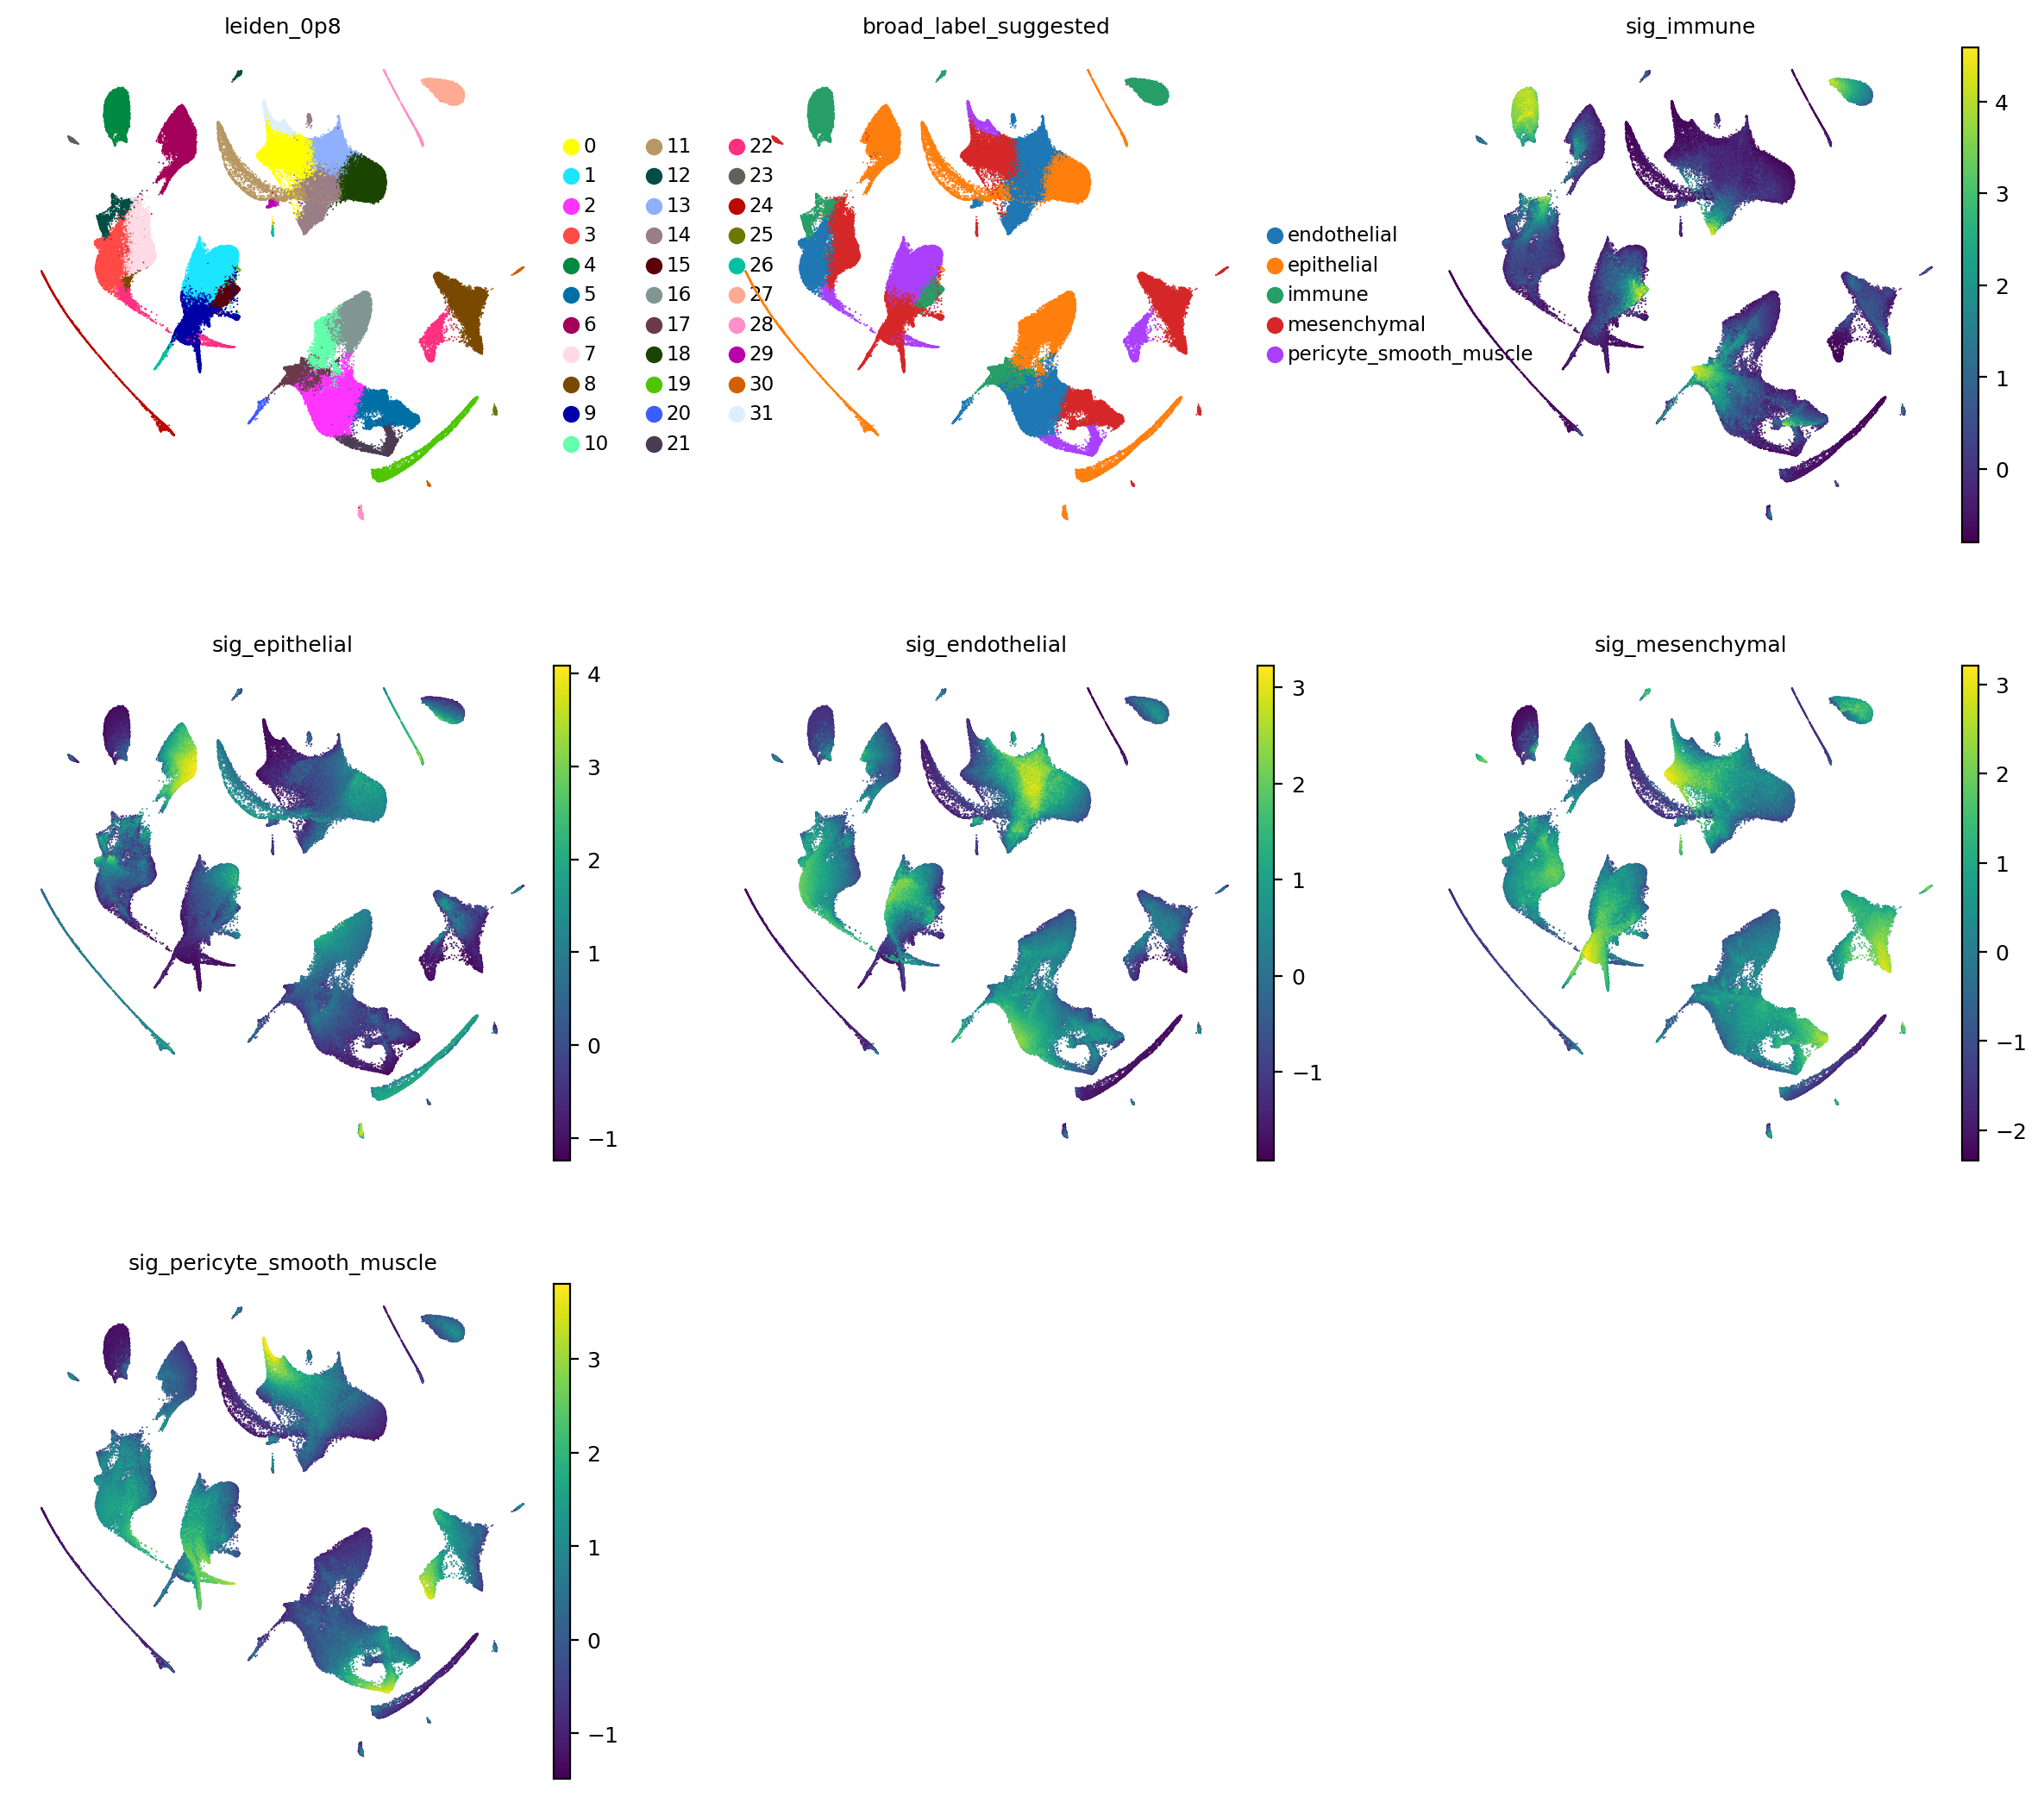

In [12]:
# ---------------------------------------------------------------------
# Calculate corrected-expression signature scores
# ---------------------------------------------------------------------
if RUN_SIGNATURE_SCORING:
    marker_genes = sorted(
        {
            gene
            for genes in MARKER_PROGRAMS.values()
            for gene in genes
        }
    )

    marker_frames = []

    for sample in SAMPLE_IDS:
        sample_rows = graph.obs[
            graph.obs["sample"].astype(str) == sample
        ]
        source_names = pd.Index(
            sample_rows[
                "source_obs_name"
            ].astype(str),
            name=None,
        )

        lazy = read_corrected_lazy(
            corrected_path(sample)
        )
        layer = resolve_corrected_layer(
            lazy
        )

        present_genes = [
            gene
            for gene in marker_genes
            if gene in pd.Index(
                lazy.var_names.astype(str)
            )
        ]

        subset = lazy[
            source_names,
            present_genes,
        ]
        matrix = materialize_array(
            subset.layers[layer]
        ).astype(np.float32, copy=False)

        matrix = np.log1p(
            np.clip(matrix, 0, None)
        )

        frame = pd.DataFrame(
            matrix,
            index=sample_rows.index,
            columns=present_genes,
        )
        marker_frames.append(frame)

        del lazy, subset, matrix
        gc.collect()

    marker_expression = pd.concat(
        marker_frames,
        axis=0,
    ).reindex(graph.obs_names)

    means = marker_expression.mean(axis=0)
    standard_deviations = (
        marker_expression.std(
            axis=0,
            ddof=0,
        ).replace(0, np.nan)
    )
    marker_z = (
        marker_expression - means
    ).div(
        standard_deviations,
        axis=1,
    ).clip(-5, 5)

    score_columns = []

    for program, genes in MARKER_PROGRAMS.items():
        present = [
            gene
            for gene in genes
            if gene in marker_z.columns
        ]
        column = f"sig_{program}"
        score_columns.append(column)

        graph.obs[column] = (
            marker_z[present].mean(axis=1)
            if present
            else np.nan
        )

    signature_cluster_mean = (
        graph.obs[
            [ANNOTATION_LEIDEN_KEY]
            + score_columns
        ]
        .groupby(
            ANNOTATION_LEIDEN_KEY,
            observed=True,
        )
        .mean()
    )

    broad_columns = [
        f"sig_{program}"
        for program in BROAD_PROGRAMS
    ]
    broad_values = signature_cluster_mean[
        broad_columns
    ]

    signature_cluster_mean[
        "broad_label_suggested"
    ] = (
        broad_values.idxmax(axis=1)
        .str.replace(
            "sig_",
            "",
            regex=False,
        )
    )

    sorted_scores = np.sort(
        broad_values.to_numpy(),
        axis=1,
    )
    signature_cluster_mean[
        "broad_score_margin"
    ] = (
        sorted_scores[:, -1]
        - sorted_scores[:, -2]
    )

    label_map = signature_cluster_mean[
        "broad_label_suggested"
    ].to_dict()

    graph.obs[
        "broad_label_suggested"
    ] = graph.obs[
        ANNOTATION_LEIDEN_KEY
    ].map(label_map)

    signature_cluster_mean.to_csv(
        TABLE_ROOT
        / f"{ANNOTATION_LEIDEN_KEY}_signature_scores.csv"
    )
    display(signature_cluster_mean)

    plot_data.obs = graph.obs.loc[
        plot_data.obs_names
    ].copy()

    sc.pl.umap(
        plot_data,
        color=[
            ANNOTATION_LEIDEN_KEY,
            "broad_label_suggested",
        ]
        + broad_columns,
        ncols=3,
        size=2,
        show=False,
    )
    plt.savefig(
        FIGURE_ROOT
        / "UMAP_broad_lung_signature_scores.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 6. Optional multi-GPU binned-Wilcoxon markers

This stage reopens the corrected-HVG staging Zarr as a Dask array, applies
`log1p` lazily, and uses RAPIDS-singlecell's Dask-compatible
`wilcoxon_binned` method. Failure is recorded but does not invalidate the
Harmony/graph checkpoint.


In [13]:
# ---------------------------------------------------------------------
# Optional GPU/Dask cluster marker ranking
# ---------------------------------------------------------------------
if RUN_GPU_CLUSTER_MARKERS:
    marker_cluster = None
    marker_client = None

    try:
        marker_cluster, marker_client, marker_cluster_kwargs = (
            start_cuda_cluster()
        )

        X_marker = da.from_zarr(
            str(STAGE_X_ZARR)
        ).astype(np.float32)
        X_marker = da.log1p(
            da.maximum(
                X_marker,
                np.float32(0),
            )
        )

        marker_adata = ad.AnnData(
            X=X_marker,
            obs=graph.obs[
                [ANNOTATION_LEIDEN_KEY]
            ].copy(),
            var=graph.var.copy(),
        )
        marker_adata.obs.index = pd.Index(
            graph.obs_names.astype(str),
            name=None,
        )
        marker_adata.var.index = pd.Index(
            graph.var_names.astype(str),
            name=None,
        )

        rsc.get.anndata_to_GPU(
            marker_adata
        )

        marker_key = (
            f"rank_genes_{ANNOTATION_LEIDEN_KEY}_"
            "rapids_wilcoxon_binned"
        )

        if rsc_version >= Version("0.14.1"):
            rsc.tl.rank_genes_groups(
                marker_adata,
                groupby=ANNOTATION_LEIDEN_KEY,
                method="wilcoxon_binned",
                n_genes=MARKER_TOP_N_GENES,
                pts=True,
                key_added=marker_key,
                multi_gpu=True,
                n_bins=MARKER_N_BINS,
                bin_range="log1p",
            )
        else:
            raise RuntimeError(
                "wilcoxon_binned requires "
                "rapids-singlecell >= 0.14.1."
            )

        marker_tables = []
        for cluster_id in graph.obs[
            ANNOTATION_LEIDEN_KEY
        ].cat.categories:
            frame = sc.get.rank_genes_groups_df(
                marker_adata,
                group=str(cluster_id),
                key=marker_key,
            )
            frame.insert(
                0,
                "cluster",
                str(cluster_id),
            )
            marker_tables.append(frame)

        cluster_markers = pd.concat(
            marker_tables,
            ignore_index=True,
        )
        cluster_markers.to_csv(
            TABLE_ROOT
            / f"{ANNOTATION_LEIDEN_KEY}_RAPIDS_wilcoxon_binned_markers.csv",
            index=False,
        )

        display(
            cluster_markers.groupby(
                "cluster"
            ).head(10)
        )

        MARKER_ERROR_JSON.unlink(
            missing_ok=True
        )

    except Exception as exc:
        error_payload = {
            "error": (
                f"{type(exc).__name__}: {exc}"
            ),
            "traceback": traceback.format_exc(),
        }
        MARKER_ERROR_JSON.write_text(
            json.dumps(
                error_payload,
                indent=2,
            )
        )
        warnings.warn(
            "GPU marker ranking failed; Harmony, UMAP, "
            "and Leiden results remain valid. "
            f"See {MARKER_ERROR_JSON}."
        )

    finally:
        if marker_client is not None:
            marker_client.close()
        if marker_cluster is not None:
            marker_cluster.close()


In [14]:
# ---------------------------------------------------------------------
# Manual annotation template
# ---------------------------------------------------------------------
MANUAL_CLUSTER_LABELS = {
    # "0": "Alveolar type 2",
    # "1": "Macrophage",
}

graph.obs["cell_type_manual"] = (
    graph.obs[
        ANNOTATION_LEIDEN_KEY
    ]
    .astype(str)
    .map(MANUAL_CLUSTER_LABELS)
    .fillna("Unassigned")
    .astype("category")
)

annotation_template = pd.DataFrame(
    {
        ANNOTATION_LEIDEN_KEY: (
            graph.obs[
                ANNOTATION_LEIDEN_KEY
            ].cat.categories.astype(str)
        )
    }
)

if "broad_label_suggested" in graph.obs:
    broad_by_cluster = (
        graph.obs[
            [
                ANNOTATION_LEIDEN_KEY,
                "broad_label_suggested",
            ]
        ]
        .drop_duplicates()
        .set_index(
            ANNOTATION_LEIDEN_KEY
        )["broad_label_suggested"]
    )
    annotation_template[
        "broad_label_suggested"
    ] = annotation_template[
        ANNOTATION_LEIDEN_KEY
    ].map(broad_by_cluster)

annotation_template[
    "reviewed_cell_type"
] = ""
annotation_template[
    "annotation_confidence"
] = ""
annotation_template["notes"] = ""

annotation_template.to_csv(
    TABLE_ROOT
    / f"{ANNOTATION_LEIDEN_KEY}_manual_annotation_template.csv",
    index=False,
)

display(annotation_template)


,leiden_0p8,broad_label_suggested,reviewed_cell_type,annotation_confidence,notes
0,0,mesenchymal,,,
1,1,pericyte_smooth_muscle,,,
2,2,endothelial,,,
3,3,endothelial,,,
4,4,immune,,,
5,5,mesenchymal,,,
6,6,epithelial,,,
7,7,mesenchymal,,,
8,8,mesenchymal,,,
9,9,mesenchymal,,,


In [15]:
# ---------------------------------------------------------------------
# Final save and provenance
# ---------------------------------------------------------------------
graph.uns[
    "integration_and_annotation_provenance"
] = {
    "samples": SAMPLE_IDS,
    "integration": "RAPIDS Harmony compatibility-safe v3 H5AD-safe",
    "batch_key": "sample",
    "harmony_audit": embedding_audit,
    "harmony_subset_neighbor_mixing": (
        safe_harmony_subset_mixing
    ),
    "integration_audit": integration_audit,
    "n_pcs_computed": int(
        graph.obsm["X_pca"].shape[1]
    ),
    "n_harmony_pcs_for_graph": int(
        N_HARMONY_PCS_FOR_GRAPH
    ),
    "neighbor_status": neighbor_status,
    "production_neighbor_algorithm": "cagra",
    "n_neighbors": int(N_NEIGHBORS),
    "umap_min_dist": float(
        UMAP_MIN_DIST
    ),
    "leiden_resolutions": [
        float(value)
        for value in LEIDEN_RESOLUTIONS
    ],
    "annotation_resolution": (
        ANNOTATION_LEIDEN_KEY
    ),
    "signature_scoring": bool(
        RUN_SIGNATURE_SCORING
    ),
    "gpu_marker_ranking_requested": bool(
        RUN_GPU_CLUSTER_MARKERS
    ),
    "source_pca_manifest": str(
        PCA_MANIFEST_JSON
    ),
    "source_corrected_stage": str(
        STAGE_X_ZARR
    ),
}

atomic_write_h5ad(
    graph,
    GRAPH_CHECKPOINT_H5AD,
)

graph.obs.to_parquet(
    TABLE_ROOT
    / "LungDev_RAPIDS_integrated_cell_metadata.parquet"
)
graph.var.to_csv(
    TABLE_ROOT
    / "LungDev_RAPIDS_integrated_gene_metadata.csv"
)

graph_manifest = {
    "shape": list(map(int, graph.shape)),
    "pca_shape": list(
        map(
            int,
            graph.obsm["X_pca"].shape,
        )
    ),
    "harmony_shape": list(
        map(
            int,
            graph.obsm[
                "X_pca_harmony"
            ].shape,
        )
    ),
    "umap_shape": list(
        map(
            int,
            graph.obsm["X_umap"].shape,
        )
    ),
    "neighbor_status": neighbor_status,
    "leiden_keys": [
        column
        for column in graph.obs
        if column.startswith("leiden_")
    ],
    "rapids_singlecell_version": str(
        rsc_version
    ),
    "graph_checkpoint": str(
        GRAPH_CHECKPOINT_H5AD
    ),
}
GRAPH_MANIFEST_JSON.write_text(
    json.dumps(
        graph_manifest,
        indent=2,
    )
)

print(graph)
print("Wrote:", GRAPH_CHECKPOINT_H5AD)
print("Wrote:", GRAPH_MANIFEST_JSON)


... storing 'broad_label_suggested' as categorical


AnnData object with n_obs × n_vars = 749761 × 3975
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'cluster', 'volume', 'surface_area', 'scale', 'component', 'cell_area_um2', 'equivalent_2um_bins', 'region', 'prior_qc_keep_bins', 'prior_qc_drop_bins', 'prior_qc_sampled_bins', 'prior_raw_label_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'sample', 'total_counts_deprecated', 'pct_counts_deprecated', 'nodep_total_counts', 'nodep_n_genes_by_counts', 'nodep_total_counts_mt', 'nodep_pct_counts_mt', 'nodep_total_counts_ribo', 'nodep_pct_counts_ribo', 'nodep_total_counts_hb', 'nodep_pct_counts_hb', 'qc_pass', 'qc_fail_reason', 'S_score', 'G2M_score', 'phase', 'cell_cycle_scored', 'resolvi_true_proportion', 'resolvi_diffusion_proportion', 'resolvi_background_proportion', 'donor', 'seg_all_nearest_neighbor_distance_um', 'seg_all_n_neig

## Recommended review sequence

1. Review UMAP by sample and each Leiden resolution.
2. Confirm no major cluster is driven primarily by mitochondrial percentage,
   low complexity, or one donor.
3. Review structural-density and density-retention patterns.
4. Review broad signature scores and top binned-Wilcoxon markers.
5. Inspect candidate clusters spatially in every donor.
6. Enter reviewed labels in the exported annotation template.
7. Recluster immune, epithelial, endothelial, and mesenchymal compartments
   separately for subtype annotation.
8. Use donor-level pseudobulk raw counts for formal differential expression;
   the graph checkpoint intentionally does not duplicate the dense corrected
   expression matrix.
